In [9]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize

In [10]:
# economic parameters
beta = 0.7
gamma = 2.0
alpha = 0.3

In [11]:
# system of equations
def euler_equation(kp, k0):

    # production today
    w = (1.0 - alpha) * k0 ** alpha

    # production tomorrow
    yp = kp ** alpha
    rp = alpha * kp ** (alpha - 1.0) - 1.0

    # consumption today and tomorrow
    c = w - kp
    cp = (1 + rp) * kp

    # euler equation
    ee_res = c ** (-gamma) - beta * (1 + rp) * cp ** (-gamma)

    return ee_res

In [12]:
# solve the model along the simulation
t_end = 100

k_ts = np.zeros(t_end)
k_ts[0] = 0.1

r_ts = np.zeros(t_end)
w_ts = np.zeros(t_end)
cy_ts = np.zeros(t_end)
co_ts = np.zeros(t_end)

for t in range(t_end-1):

    # solve system of equations given the current capital stock
    lb = 0.01
    ub = 0.99 * (1.0 - alpha) * k_ts[t] ** alpha
    sol = scipy.optimize.root_scalar(euler_equation, bracket=[lb, ub], args=(k_ts[t]), method='brentq')
    k_ts[t+1] = sol.root

    # compute factor prices and utility
    r_ts[t] = alpha * k_ts[t] ** (alpha - 1) - 1
    w_ts[t] = (1 - alpha) * k_ts[t] ** alpha
    cy_ts[t] = w_ts[t] - k_ts[t+1]
    co_ts[t] = (1 + r_ts[t]) * k_ts[t]

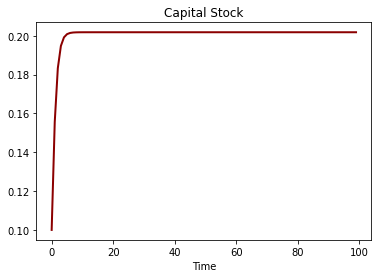

In [13]:
plt.figure()
plt.plot(np.arange(t_end), k_ts, color='darkred', linewidth=2)
plt.title('Capital Stock')
plt.xlabel('Time')
plt.show()